In [1]:
import numpy as np
from scipy import stats
from scipy import signal
import math
from scipy.stats import circmean
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
from os.path import sep
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from scipy.special import i0
from scipy.interpolate import UnivariateSpline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import pearsonr,linregress
from scipy.stats import spearmanr
from scipy.signal import correlate
from scipy.stats import levene
from scipy.stats import circvar
from sklearn.linear_model import HuberRegressor
from matplotlib.cm import plasma
from matplotlib.colors import Normalize,LinearSegmentedColormap
from pathlib import Path
import sys

In [2]:
repo_root = Path('/home/tianhaoqiu/Documents/GitHub/2p_analysis')
sys.path.insert(0, str(repo_root))

In [3]:
from fly2p_function_TQ.imaging_2p_fixed_heading_period_analysis import find_stop_period_on_heading,PVA_during_stopPeriod,forwrad_speed_during_stopPeriod,bump_amplitude_during_stopPeriod,calculate_angle_difference_between_two_time_point, stopping_period_signal_decay,find_qualified_stopping_period, PVA_strength_during_stopPeriod,permutation_test_median
from fly2p_function_TQ.imaging_2p_fixed_heading_period_analysis import calculate_angle_difference_between_two_time_point,run_ANOVA_for_comparing_across_genotypes,plot_stopping_period_signal,calculate_stop_signal_in_separate_fly,run_fixed_heading_period_analysis_across_trial, plot_fly_data_histograms_fly_wise,plot_fly_data_density_fly_wise,plot_stop_drift_rate_heatmaps,extract_signal_during_entire_stop
from fly2p_function_TQ.imaging_2p_fictrac_imaging_alignment import fictrack_signal_decoding,moving_wrapped_plot_by_offset
from fly2p_function_TQ.imaging_2p_preprocessing import low_pass_filter_TQ
from fly2p_function_TQ.imaging_2p_PVA_functions import calcualteBumpAmplitude ,calcualteBumpAmplitude_V2_green, calcualteBumpAmplitude_V3, calculateBumpWidth_v1,von_Mises_fitting_dff_TQ, PVA_radian_to_angle,calcualteBumpAmplitude_V4,PVAangleToRoi,strong_PVA_duration,plot_bump_shape_comparison,plot_strong_signal_frame_pva_histogram

In [4]:
def _fly_list_key_for(amplitude_key: str) -> str:
    """Pick the right fly-ID list key based on the amplitude key name."""
    if "left_bridge" in amplitude_key:
        return "FlyTrial_info_qualified_stop_left"
    if "right_bridge" in amplitude_key:
        return "FlyTrial_info_qualified_stop_right"
    return "FlyTrial_info_qualified_stop"

def _normalize_cols_at_index(df: pd.DataFrame, idx0: int) -> pd.DataFrame:
    out = df.copy()
    denom = out.iloc[idx0, :].to_numpy()
    # guard against zeros
    denom = np.where(np.isfinite(denom) & (np.abs(denom) > 1e-12), denom, np.nan)
    out = out / denom
    return out

def _smooth_cols(df: pd.DataFrame, sigma_bins: float | int) -> pd.DataFrame:
    if not sigma_bins or sigma_bins <= 0:
        return df
    # apply per column; keep NaNs
    def _gf1d(x):
        x = x.to_numpy(dtype=float)
        mask = np.isfinite(x)
        if mask.sum() < 3:
            return x
        # simple NaN-handling: interpolate across NaNs before smoothing, then put them back
        xp = np.where(mask)[0]
        fp = x[mask]
        xi = np.arange(x.size)
        xi_vals = np.interp(xi, xp, fp)
        yi = gaussian_filter1d(xi_vals, sigma=sigma_bins, mode="nearest")
        # restore NaNs where the entire column was NaN at idx0, etc.
        yi[~mask] = np.nan
        return yi
    sm = df.apply(_gf1d, axis=0, result_type='expand')
    sm.columns = df.columns
    return sm

def _per_fly_average(df: pd.DataFrame, fly_ids: list[str]) -> pd.DataFrame:
    """Average columns that belong to the same fly (NaN-safe)."""
    fly_ids = list(fly_ids)
    if df.shape[1] != len(fly_ids):
        raise ValueError(f"Columns ({df.shape[1]}) != number of fly IDs ({len(fly_ids)})")
    # group columns by fly_id
    per_fly = {}
    for j, fid in enumerate(fly_ids):
        per_fly.setdefault(fid, []).append(j)
    # mean across that fly's columns
    out_cols = []
    out_names = []
    for fid, idxs in per_fly.items():
        arr = df.iloc[:, idxs].to_numpy(dtype=float)  # (T, n_trials_this_fly)
        with np.errstate(invalid="ignore"):
            m = np.nanmean(arr, axis=1)               # (T,)
        out_cols.append(m)
        out_names.append(fid)
    out = pd.DataFrame(np.column_stack(out_cols), index=df.index, columns=out_names)
    return out

def plot_bump_decay_comparison(
    genotype_dicts: dict,
    amplitude_key: str = "bump_amplitude_max_min",
    bin_size_s: float = 0.2,
    pre_seconds: float = 1.0,                 # how much pre-stop time exists in each column
    smooth_sigma_bins: float | int = 8,       # Gaussian sigma in *bins* (set 0/None to disable)
    normalize_each_trial: bool = True,        # normalize each trial at t=0 before per-fly mean
    smoothing_stage: str = "after",           # "after" (default) or "before"
    show_sem: bool = False,                   # add shaded SEM per genotype
    plot_range_s: tuple[float,float] = (0, 20),
    labels: dict | None = None,               # optional mapping {genotype_key: pretty_name}
    linewidth: float = 3.5,
):
    """
    genotype_dicts: {"delta7-PB": delta7_syt7f_decay_df, "EPG-PB": EPG_syt7f_decay_df, ...}
    Each value is the dict returned by `extract_signal_during_entire_stop`.
    """
    # Build time axis and zero index from df shape
    # (assumes all genotypes share same number of rows; if not, we handle per genotype)
    curves = {}  # collect for legend/return

    for gname, gdict in genotype_dicts.items():
        if amplitude_key not in gdict:
            print(f"[WARN] {gname}: key '{amplitude_key}' not found, skipping.")
            continue
        df = gdict[amplitude_key].copy()  # (T, N_trials)
        if not isinstance(df, pd.DataFrame) or df.empty:
            print(f"[WARN] {gname}: empty DataFrame for '{amplitude_key}', skipping.")
            continue

        # time array for this genotype
        T = df.shape[0]
        zero_idx = int(round(pre_seconds / bin_size_s))
        t = (np.arange(T, dtype=float) - zero_idx) * bin_size_s

        # Only keep requested range
        lo, hi = plot_range_s
        keep = (t >= lo - pre_seconds) & (t <= hi)
        # but we will finally slice at t>=0 for plotting below; keep extra indices for normalization
        # Normalize & smooth pipeline
        fly_key = _fly_list_key_for(amplitude_key)
        fly_ids = gdict.get(fly_key, None)
        if fly_ids is None:
            raise KeyError(f"{gname}: missing fly list key '{fly_key}'")

        work = df.copy()

        if smoothing_stage == "before" and smooth_sigma_bins and smooth_sigma_bins > 0:
            work = _smooth_cols(work, smooth_sigma_bins)

        if normalize_each_trial:
            work = _normalize_cols_at_index(work, zero_idx)

        # average trials within the same fly
        per_fly = _per_fly_average(work, fly_ids)

        if smoothing_stage == "after" and smooth_sigma_bins and smooth_sigma_bins > 0:
            per_fly = _smooth_cols(per_fly, smooth_sigma_bins)
            # smoothing may move the value at t=0 slightly; renormalize per fly to keep anchor at 1
            for c in per_fly.columns:
                denom = per_fly.iloc[zero_idx, per_fly.columns.get_loc(c)]
                denom = denom if (np.isfinite(denom) and abs(denom) > 1e-12) else np.nan
                per_fly[c] = per_fly[c] / denom

        # mean (and SEM) across flies
        with np.errstate(invalid="ignore"):
            mean_curve = np.nanmean(per_fly.to_numpy(dtype=float), axis=1)
            if show_sem:
                n_flies = np.sum(~np.isnan(per_fly.iloc[zero_idx, :].to_numpy()))
                sem_curve = np.nanstd(per_fly.to_numpy(dtype=float), axis=1, ddof=1) / np.sqrt(max(n_flies, 1))
            else:
                sem_curve = None

        # Final slice to [0, hi]
        keep_final = (t >= plot_range_s[0]) & (t <= plot_range_s[1])
        curves[gname] = {
            "t": t[keep_final],
            "mean": mean_curve[keep_final],
            "sem": sem_curve[keep_final] if sem_curve is not None else None,
            "n_flies": per_fly.shape[1],
            "n_trials": df.shape[1],
        }

    # ---- Plot ----
    if len(curves) == 0:
        raise ValueError("No curves to plot. Check keys and inputs.")

    # simple color cycle
    colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
    while len(colors) < len(curves):
        colors = colors + colors  # extend if needed

    plt.figure(figsize=(20, 8))
    for i, (gname, cdict) in enumerate(curves.items()):
        label = labels.get(gname, gname) if labels else gname
        t = cdict["t"]
        y = cdict["mean"]
        plt.plot(t, y, linewidth=linewidth, label=f"{label} (n={cdict['n_flies']})", color=colors[i])
        if show_sem and (cdict["sem"] is not None):
            sem = cdict["sem"]
            plt.fill_between(t, y - sem, y + sem, alpha=0.2, color=colors[i])

    # ticks & cosmetics
    xticks = np.arange(plot_range_s[0], plot_range_s[1] + 1e-9, 1.0)
    plt.xticks(xticks, xticks.astype(int), fontsize=16)
    plt.yticks(fontsize=16)
    plt.yticks([0,0.5,1,1.5])
    plt.xlim(plot_range_s)
    plt.ylim (0,1.5)
    plt.xlabel("Time (s)", fontsize=23)
    plt.ylabel("Bump Amplitude", fontsize=23)
    plt.title(f"Average {amplitude_key} decay ({plot_range_s[0]}–{plot_range_s[1]} s after stop)\n",
              fontsize=30)
    plt.legend(fontsize=16, frameon=False)
    plt.tight_layout()
    #plt.savefig('syt7f_dark_Bump_amplitude_max_min_0_20s_updated.svg', format='svg')
    plt.show()

    return curves  # handy if you want the numbers later


In [32]:
def plot_bump_decay_comparison(
    genotype_dicts: dict,
    amplitude_key: str = "bump_amplitude_max_min",
    bin_size_s: float = 0.2,
    pre_seconds: float = 1.0,
    smooth_sigma_bins: float | int = 8,
    normalize_each_trial: bool = True,
    smoothing_stage: str = "after",
    show_sem: bool = False,
    plot_range_s: tuple[float, float] = (0, 20),
    labels: dict | None = None,
    linewidth: float = 3.5,
    # NEW
    plot_trials: bool = False,
    trials_fly_selector: dict | str | None = None,
    trial_alpha: float = 0.25,
    trial_lw: float = 1.2,
):
    curves = {}

    for gname, gdict in genotype_dicts.items():
        if amplitude_key not in gdict:
            print(f"[WARN] {gname}: key '{amplitude_key}' not found, skipping.")
            continue
        df = gdict[amplitude_key].copy()
        if not isinstance(df, pd.DataFrame) or df.empty:
            print(f"[WARN] {gname}: empty DataFrame for '{amplitude_key}', skipping.")
            continue

        T = df.shape[0]
        zero_idx = int(round(pre_seconds / bin_size_s))
        t = (np.arange(T, dtype=float) - zero_idx) * bin_size_s
        keep_final = (t >= plot_range_s[0]) & (t <= plot_range_s[1])

        fly_key = _fly_list_key_for(amplitude_key)
        fly_ids = gdict.get(fly_key, None)
        if fly_ids is None:
            raise KeyError(f"{gname}: missing fly list key '{fly_key}'")

        work = df.copy()

        if smoothing_stage == "before" and smooth_sigma_bins and smooth_sigma_bins > 0:
            work = _smooth_cols(work, smooth_sigma_bins)

        if normalize_each_trial:
            work = _normalize_cols_at_index(work, zero_idx)

        # --- decide trial overlays ---
        trial_curves = None
        if plot_trials:
            idxs = list(range(work.shape[1]))  # default: ALL trials
            if trials_fly_selector is not None:
                if isinstance(trials_fly_selector, str):
                    if trials_fly_selector.upper() != "ALL":
                        raise ValueError("trials_fly_selector as a string must be 'ALL' or use a dict per genotype.")
                elif isinstance(trials_fly_selector, dict):
                    if gname in trials_fly_selector:
                        sel = trials_fly_selector[gname]
                        if isinstance(sel, str):
                            sel = [sel]
                        if len(sel) == 1 and sel[0].upper() == "ALL":
                            idxs = list(range(work.shape[1]))
                        else:
                            idxs = [j for j, fid in enumerate(fly_ids) if fid in sel]
                else:
                    raise TypeError("trials_fly_selector must be None, 'ALL', or dict {genotype: fly_id(s)}")
            if len(idxs) > 0:
                trial_curves = work.iloc[:, idxs].copy()

        # per-fly average
        per_fly = _per_fly_average(work, fly_ids)

        if smoothing_stage == "after" and smooth_sigma_bins and smooth_sigma_bins > 0:
            per_fly = _smooth_cols(per_fly, smooth_sigma_bins)
            # re-anchor per fly at t=0
            for c in per_fly.columns:
                denom = per_fly.iat[zero_idx, per_fly.columns.get_loc(c)]
                denom = denom if (np.isfinite(denom) and abs(denom) > 1e-12) else np.nan
                per_fly[c] = per_fly[c] / denom

            # --- FIXED: renorm trials using positional indices ---
            if trial_curves is not None:
                trial_curves = _smooth_cols(trial_curves, smooth_sigma_bins)
                for j in range(trial_curves.shape[1]):
                    denom = trial_curves.iat[zero_idx, j]
                    denom = denom if (np.isfinite(denom) and abs(denom) > 1e-12) else np.nan
                    trial_curves.iloc[:, j] = trial_curves.iloc[:, j] / denom

        # mean (and optional SEM) across flies
        with np.errstate(invalid="ignore"):
            mean_curve = np.nanmean(per_fly.to_numpy(dtype=float), axis=1)
            if show_sem:
                n_flies = np.sum(~np.isnan(per_fly.iloc[zero_idx, :].to_numpy()))
                sem_curve = np.nanstd(per_fly.to_numpy(dtype=float), axis=1, ddof=1) / np.sqrt(max(n_flies, 1))
            else:
                sem_curve = None

        # pack
        curves[gname] = {
            "t": t[keep_final],
            "mean": mean_curve[keep_final],
            "sem": sem_curve[keep_final] if sem_curve is not None else None,
            "n_flies": per_fly.shape[1],
            "n_trials": df.shape[1],
        }
        if trial_curves is not None:
            curves[gname]["trial_t"] = t[keep_final]
            curves[gname]["trial_matrix"] = trial_curves.to_numpy(dtype=float)[keep_final, :]
            curves[gname]["trial_cols"] = list(trial_curves.columns)

    # --- plot ---
    if len(curves) == 0:
        raise ValueError("No curves to plot. Check keys and inputs.")

    colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
    while len(colors) < len(curves):
        colors = colors + colors

    plt.figure(figsize=(20, 8))
    for i, (gname, cdict) in enumerate(curves.items()):
        label = labels.get(gname, gname) if labels else gname
        t = cdict["t"]
        y = cdict["mean"]
        plt.plot(t, y, linewidth=linewidth, label=f"{label} (n={cdict['n_flies']})", color=colors[i])
        if show_sem and (cdict["sem"] is not None):
            sem = cdict["sem"]
            plt.fill_between(t, y - sem, y + sem, alpha=0.2, color=colors[i])
        if plot_trials and ("trial_matrix" in cdict):
            tm = cdict["trial_matrix"]; tt = cdict["trial_t"]
            for k in range(tm.shape[1]):
                plt.plot(tt, tm[:, k], linewidth=trial_lw, alpha=trial_alpha, color=colors[i])

    xticks = np.arange(plot_range_s[0], plot_range_s[1] + 1e-9, 1.0)
    plt.xticks(xticks, xticks.astype(int), fontsize=16)
    plt.yticks(fontsize=16)
    plt.yticks([0, 0.5, 1, 1.5])
    plt.xlim(plot_range_s)
    plt.ylim(0, 1.5)
    plt.xlabel("Time (s)", fontsize=23)
    plt.ylabel("Bump Amplitude", fontsize=23)
    plt.title(f"Average {amplitude_key} decay ({plot_range_s[0]}–{plot_range_s[1]} s after stop)\n",
              fontsize=30)
    plt.legend(fontsize=16, frameon=False)
    plt.tight_layout()
    plt.show()

    return curves




In [5]:
stable_PVA_threshold = 67.5
trial_condition = 'dark'
dual_imaging = 0
bump_amplitude_stopping_duration = 20
#200ms bin size
bump_amplitude_stopping_bin_size = 0.2
active_period_before_len =1

In [7]:
delta7_syt7f_decay_df = extract_signal_during_entire_stop('/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/dark_cl_Ca_imaging/delta7/delta7_PB-updated/dark',0,bump_amplitude_stopping_duration,False)
EPG_syt7f_decay_df = extract_signal_during_entire_stop('/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/dark_cl_Ca_imaging/EPG/EPG_PB(syt)/updated/dark',0,bump_amplitude_stopping_duration,False)
PENb_syt7f_decay_df = extract_signal_during_entire_stop('/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/dark_cl_Ca_imaging/PENb/PENb_EB(syt)_(16_ROI_F)/dark',0,bump_amplitude_stopping_duration,False)
delta7_iGluSnFRA184S_decay_df = extract_signal_during_entire_stop('/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/NTs_imaging/delta7_iGluSnFRA184S/updated/dark',0,bump_amplitude_stopping_duration,False)
delta7_iGluSnFR3_decay_df = extract_signal_during_entire_stop('/home/tianhaoqiu/Documents/GitHub/2p_analysis/preprocessing_output/normalized/NTs_imaging/delta7_iGluSnFR3/dark',0,bump_amplitude_stopping_duration,False)

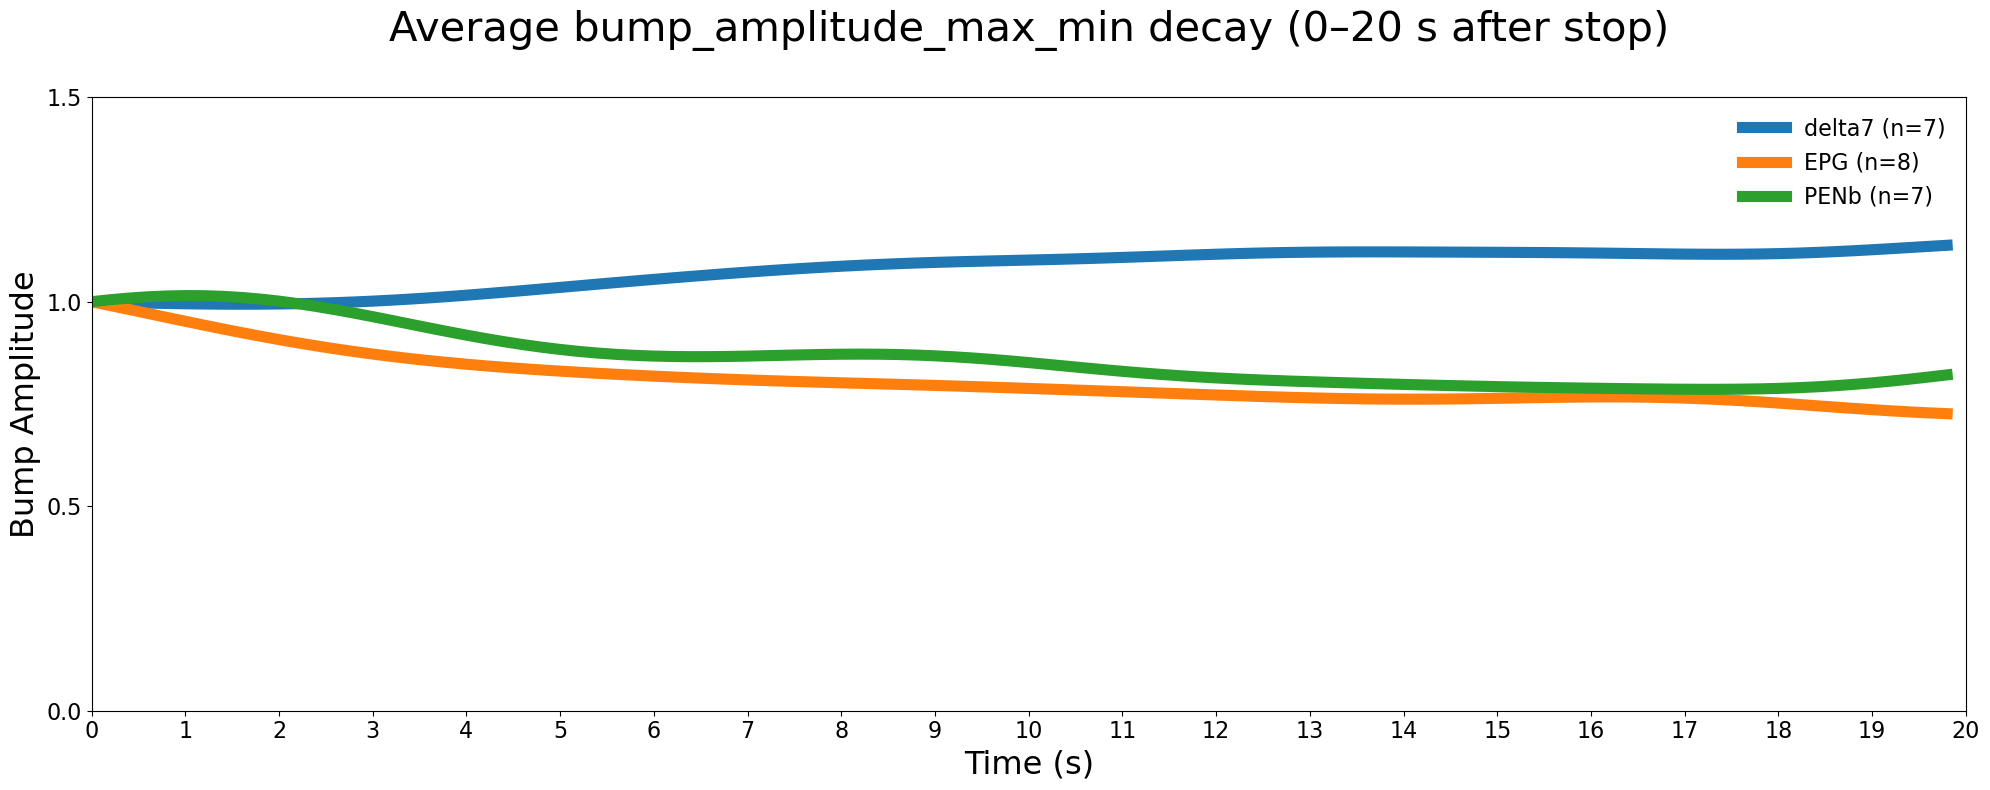

In [33]:
# Example genotype dicts (rename to whatever variables you actually have)
genotypes = {
    "delta7": delta7_syt7f_decay_df,
    "EPG":    EPG_syt7f_decay_df,
    "P-EN2-EB":  PENb_syt7f_decay_df,
    #"P-FNd-FB":  PFNd_syt7f_decay_df,
    #"delta7-iGluA184S":delta7_iGluSnFRA184S_decay_df,
    #"P-EG-EB":   PEG_syt7f_decay_df,
    #"delta7-iGlu3":delta7_iGluSnFR3_decay_df,
}

curves = plot_bump_decay_comparison(
    genotype_dicts=genotypes,
    amplitude_key="bump_amplitude_max_min",  # or 'bump_amplitude_PVA', ...
    bin_size_s=0.2,
    pre_seconds=1.0,                         # you extracted with active_period_before_len=1
    smooth_sigma_bins=8,                     # tune this (in *bins*). Set 0/None to disable
    normalize_each_trial=False,               # trial-level norm @ t=0, then per-fly mean
    smoothing_stage="after",                 # 'before' to smooth first (then norm)
    show_sem=False,                          # True to add shaded SEM
    plot_range_s=(0, 20),
    labels={"delta7": "delta7", "EPG": "EPG", "P-EN2-EB": "PENb"},
    linewidth=8,
)


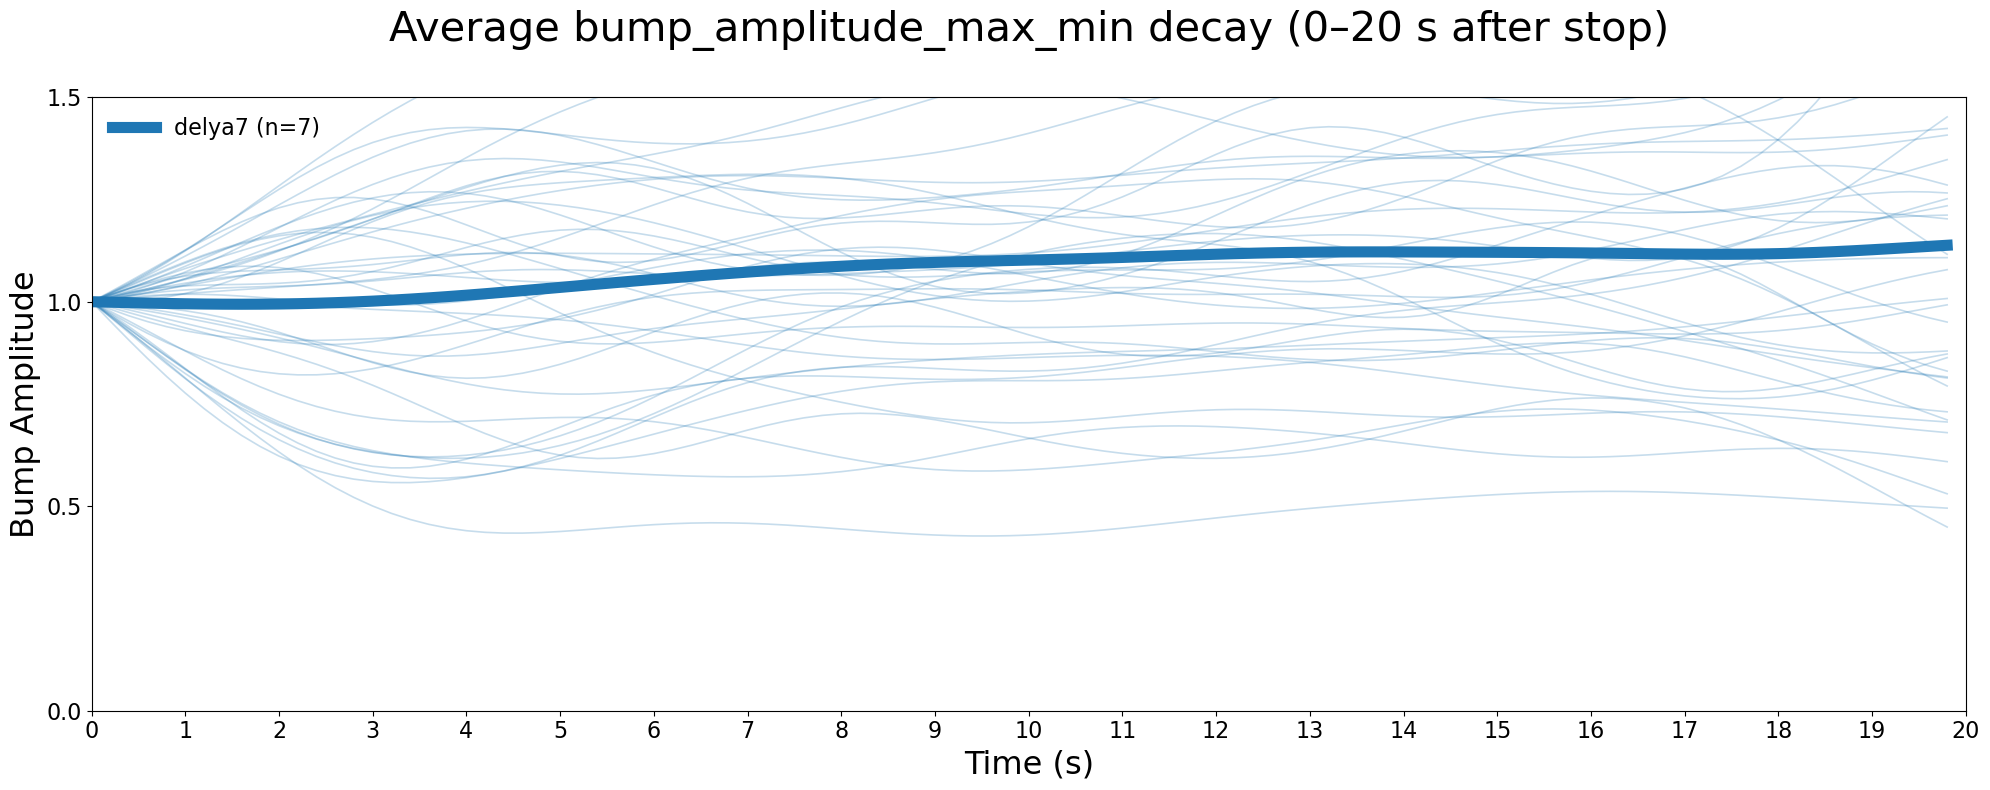

In [42]:
# Example genotype dicts (rename to whatever variables you actually have)
genotypes = {
    "delta7": delta7_syt7f_decay_df,
}

curves = plot_bump_decay_comparison(
    genotype_dicts=genotypes,
    amplitude_key="bump_amplitude_max_min",  # or 'bump_amplitude_PVA', ...
    bin_size_s=0.2,
    pre_seconds=1.0,                         # you extracted with active_period_before_len=1
    smooth_sigma_bins=8,                     # tune this (in *bins*). Set 0/None to disable
    normalize_each_trial=False,               # trial-level norm @ t=0, then per-fly mean
    smoothing_stage="after",                 # 'before' to smooth first (then norm)
    show_sem=False,                          # True to add shaded SEM
    plot_range_s=(0, 20),
    labels={"delta7": "delya7"},
    linewidth=8,
    plot_trials=True,
    trials_fly_selector = None,
)

In [12]:
import numpy as np
import pandas as pd

def per_fly_per_second_amplitude_by_genotype(
    genotype_dicts: dict,
    *,
    amplitude_key: str = "bump_amplitude_max_min",
    bin_size_s: float = 0.2,
    pre_seconds: float = 1.0,
    smooth_sigma_bins: float | int = 8,
    normalize_each_trial: bool = True,
    smoothing_stage: str = "after",          # "after" (default) or "before"
    seconds_range: tuple[float, float] = (0, 20),
    return_summary: bool = True              # also return per-second mean ± SEM across flies
):
    """
    Returns
    -------
    per_second : dict[str, pd.DataFrame]
        For each genotype, a DataFrame with index = integer seconds (e.g., 0..19)
        and columns = fly IDs. Values are the mean amplitude within each 1 s bin
        (e.g., [s, s+1) ), NaN-safe.

    summary (optional) : dict[str, pd.DataFrame]
        If return_summary=True, for each genotype returns a DataFrame with columns:
        ['mean', 'sem', 'n'] giving per-second across-fly statistics.
    """
    per_second: dict[str, pd.DataFrame] = {}
    summary: dict[str, pd.DataFrame] = {}

    s0 = int(np.floor(seconds_range[0]))
    s1 = int(np.ceil(seconds_range[1]))  # exclusive upper bound for bins [s, s+1)

    for gname, gdict in genotype_dicts.items():
        if amplitude_key not in gdict:
            continue

        df = gdict[amplitude_key]
        if not isinstance(df, pd.DataFrame) or df.empty:
            continue

        # --- time axis ---
        T = df.shape[0]
        zero_idx = int(round(pre_seconds / bin_size_s))
        t = (np.arange(T, dtype=float) - zero_idx) * bin_size_s

        # --- fly IDs for this amplitude key ---
        fly_key = _fly_list_key_for(amplitude_key)
        fly_ids = gdict.get(fly_key, None)
        if fly_ids is None:
            continue

        # --- preprocessing: smoothing/normalization/per-fly average (your pipeline) ---
        work = df.copy()
        if smoothing_stage == "before" and smooth_sigma_bins and smooth_sigma_bins > 0:
            work = _smooth_cols(work, smooth_sigma_bins)
        if normalize_each_trial:
            work = _normalize_cols_at_index(work, zero_idx)
        per_fly = _per_fly_average(work, fly_ids)
        if smoothing_stage == "after" and smooth_sigma_bins and smooth_sigma_bins > 0:
            per_fly = _smooth_cols(per_fly, smooth_sigma_bins)
            # re-anchor to 1 at t=0 per fly
            for c in per_fly.columns:
                denom = per_fly.iloc[zero_idx, per_fly.columns.get_loc(c)]
                denom = denom if (np.isfinite(denom) and abs(denom) > 1e-12) else np.nan
                per_fly[c] = per_fly[c] / denom

        # --- bin to 1-second intervals and average within each bin, per fly ---
        sec_idx = np.floor(t).astype(int)                 # second label per row
        mask = (sec_idx >= s0) & (sec_idx < s1) & (t >= seconds_range[0]) & (t <= seconds_range[1])
        df_bin = per_fly.loc[mask, :].copy()
        sec_labels = pd.Index(sec_idx[mask], name="second")

        # group rows by second, then mean across rows for each fly (columns)
        df_sec = df_bin.groupby(sec_labels).mean()        # (n_seconds, n_flies)
        # ensure every second s0..s1-1 is present
        df_sec = df_sec.reindex(range(s0, s1), fill_value=np.nan)

        per_second[gname] = df_sec

        if return_summary:
            # across-fly mean ± SEM for each second
            with np.errstate(invalid="ignore"):
                n = df_sec.count(axis=1)  # number of finite fly values each second
                mu = df_sec.mean(axis=1, skipna=True)
                sd = df_sec.std(axis=1, ddof=1, skipna=True)
                sem = sd / np.sqrt(n.where(n > 0, np.nan))
            summary[gname] = pd.DataFrame({"mean": mu, "sem": sem, "n": n})

    return (per_second, summary) if return_summary else per_second



In [13]:
# Get per-fly per-second means from 0–20 s
per_sec, per_sec_summary = per_fly_per_second_amplitude_by_genotype(
    genotypes,
    amplitude_key="bump_amplitude_max_min",
    seconds_range=(-1, 20),
    return_summary=True
)





In [96]:
#per_sec['delta7'].to_csv('delta7_stop_period_amplitude_max_min.csv', index=False)